# Langgraph Basics

In [71]:
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from typing import TypedDict, Optional

from IPython.display import Image, display

from dotenv import load_dotenv
load_dotenv()

True

In [4]:
openai_llm = ChatOpenAI(model="gpt-4.1-nano")

# Components of LangGraph

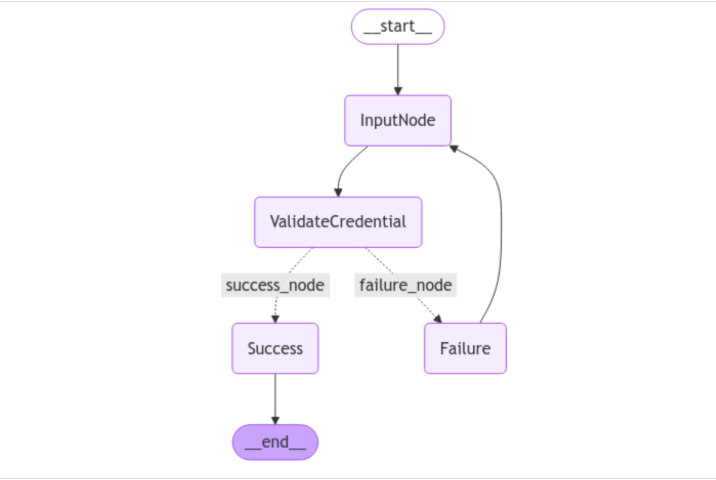

## 1. States

States represent the current condition or context within a workflow. They store and manage information as the agent progresses from one node to the next.

### Define class for State

In [ ]:
# Instead of TypedDict, we could also use Pydantic
class AuthState(TypedDict):
    username: Optional[str] 
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

### Example Objects and Their States

#### Object 1: Successful Login

In [7]:
auth_state_1: AuthState = {
    "username": "alice123",
    "password": "123",
    "is_authenticated": True,
    "output": "Login successful."
}
print(f"auth_state_1: {auth_state_1}")

auth_state_1: {'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


#### Object 2: Unsuccessful Login

In [8]:
auth_state_2: AuthState = {
    "username":"",
    "password": "wrongpassword",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_2: {auth_state_2}")

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


## 2. Nodes

Nodes are the core units of action in LangGraph. Each node represents a specific task or operation that the AI agent needs to perform.

### Define input_node

In [ ]:
def input_node(state):
    print(state)
    if state.get('username', "") =="":
        state['username'] = input("What is your username?")

    password = input("Enter your password: ")

    return {"password":password} # returning value like this, will update state for graph Nodes internally. When we will call next node and get password there from state(state['password']), next node will get this returned password.

In [10]:
input_node(auth_state_1) 
# Upon calling this, it directed us to enter password. I entered: pass

{'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


{'password': 'pass'}

In [16]:
print(auth_state_1)

{'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


In [11]:
input_node(auth_state_2) 
# Upon calling this, it directed us to enter Username and then password. I entered: my_name first, then pass

{'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


{'password': 'pass'}

In [13]:
print(auth_state_2)

{'username': 'my_name', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


### Define validate_credentials_node

In [14]:
def validate_credentials_node(state):
    # Extract username and password from the state
    username = state.get("username", "")
    password = state.get("password", "")

    print("Username :", username, "\nPassword :", password)
    # Simulated credential validation
    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False

    # Return the updated state with authentication result
    return {"is_authenticated": is_authenticated}

#### 1. Incorrect Format

In [17]:
validate_credentials_node(auth_state_1)

Username : alice123 
Password : 123


{'is_authenticated': False}

#### 2. Incorrect Format

In [22]:
auth_state_3: AuthState = {
    "username":"test_user",
    "password":  "secure_password",
}
# print(f"auth_state_3: {auth_state_3}")

validate_credentials_node(auth_state_3)

Username : test_user 
Password : secure_password


{'is_authenticated': True}

### Defining the Success Node

In [23]:
def success_node(state):
    return {"output": "Authentication successful! Welcome."}

In [24]:
success_node(auth_state_3)

{'output': 'Authentication successful! Welcome.'}

### Defining the Failure Node

In [ ]:
def failure_node(state):
    return {"output": "Not Successful, please try again!"}

### Defining the Router Node

The router node acts as a decision-making point in the workflow. It takes the current state as input and determines the next node to execute based on the is_authenticated value in the state.

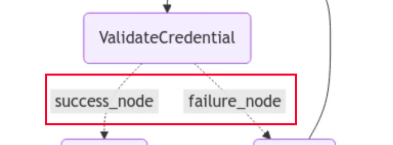

In [51]:
def router(state):
    if state['is_authenticated']:
        return "success_node"
    else:
        return "failure_node"

## Creating the Graph  


In [52]:
# Create an instance of StateGraph with the GraphState structure
workflow = StateGraph(AuthState)
workflow

### Adding Nodes to the Graph

In [53]:
workflow.add_node("InputNode", input_node)
workflow.add_node("ValidateCredential", validate_credentials_node)
workflow.add_node("Success", success_node)
workflow.add_node("Failure", failure_node)

## 3. Edges

Edges define the connections between nodes and represent the flow of execution within the graph. They dictate how the AI agent transitions from one task to another based on predefined logic or conditions. 

In the authentication workflow, edges guide the application flow, determining the path taken based on the results of each node's execution.

In [54]:
# workflow.add_edge(START, "InputNode") # its same as set_entry_point
workflow.set_entry_point("InputNode")
workflow.add_edge("InputNode", "ValidateCredential")
workflow.add_conditional_edges("ValidateCredential", router, {"success_node": "Success", "failure_node": "Failure"})
workflow.add_edge("Failure", "InputNode")
workflow.add_edge("Success", END)


## Compiling the Workflow

In [55]:
app = workflow.compile()

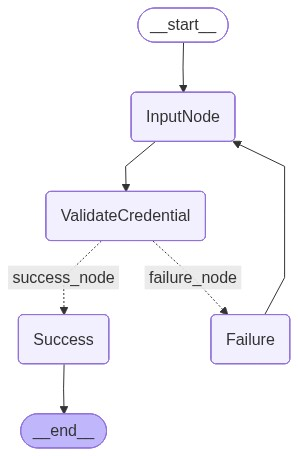

In [56]:
display(Image(app.get_graph().draw_mermaid_png()))


In [57]:
inputs = {"username": "test_user"}
result = app.invoke(inputs) 
print(result)
# upon running this cell, I put "secure_password" into terminal input. then got final result

{'username': 'test_user'}
Username : test_user 
Password : secure_password
{'username': 'test_user', 'password': 'secure_password', 'is_authenticated': True, 'output': 'Authentication successful! Welcome.'}


In [58]:
result['output']

'Authentication successful! Welcome.'

---

# Building a QA Workflow

In [ ]:
# Define the state
class QAState(TypedDict):
    question: Optional[str] # 'question' stores the user's input question. It can be a string or None if not provided.
    context: Optional[str] # 'context' stores relevant context about guided project and langgraph
    answer: Optional[str] # 'answer' stores the generated response or answer. It can be None until the answer is generated.

In [61]:
# Create an example object
qa_state_example = QAState(
    question="What is the purpose of this guided project?",
    context="This project focuses on building a chatbot using Python.",
    answer=None
)

# Print the attributes
for key, value in qa_state_example.items():
    print(f"{key}: {value}")

qa_state_example

question: What is the purpose of this guided project?
context: This project focuses on building a chatbot using Python.
answer: None


{'question': 'What is the purpose of this guided project?',
 'context': 'This project focuses on building a chatbot using Python.',
 'answer': None}

In [62]:
# Defining Node
def input_validation_node(state):
    question = state.get("question", "").strip() # Extract the question from the state, and strip any leading or trailing spaces
    
    if not question:
        return {"valid": False, "error": "Question cannot be empty."}
    
    return {"valid": True} # If the question is valid, return valid status

In [63]:
input_validation_node(qa_state_example)

{'valid': True}

In [ ]:
# Defining a Node
def context_provider_node(state):
    question = state.get("question", "").lower()
    
    # Check if the question is related to the guided project or langgraph, then return context with values otherwise return context with None
    if "langgraph" in question or "guided project" in question:
        context = (
            "This guided project is about using LangGraph, a Python library to design state-based workflows. "
            "LangGraph simplifies building complex applications by connecting modular nodes with conditional edges."
        )
        return {"context": context}
    
    return {"context": None}

In [ ]:
# Define a node
def llm_qa_node(state):
    # Extract the question and context from the state
    question = state.get("question", "")
    context = state.get("context", None)

    # Check for missing context and return a fallback response
    if not context:
        return {"answer": "I don't have enough context to answer your question."}

    # Construct the prompt dynamically
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer the question based on the provided context."

    try:
        response = openai_llm.invoke(prompt)
        return {"answer": response.content.strip()}
    except Exception as e:
        return {"answer": f"An error occurred: {str(e)}"}

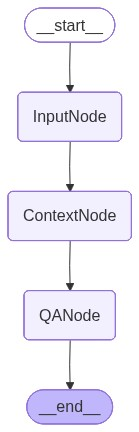

In [73]:
qa_workflow = StateGraph(QAState)

qa_workflow.add_node("InputNode", input_validation_node)
qa_workflow.add_node("ContextNode", context_provider_node)
qa_workflow.add_node("QANode", llm_qa_node)

# qa_workflow.set_entry_point("InputNode")
qa_workflow.add_edge(START, "InputNode") # its same as set_entry_point
qa_workflow.add_edge("InputNode", "ContextNode")
qa_workflow.add_edge("ContextNode", "QANode")
qa_workflow.add_edge("QANode", END)

qa_app = qa_workflow.compile()
display(Image(qa_app.get_graph().draw_mermaid_png()))


In [74]:
qa_app.invoke({"question": "What is the weather today?"})

{'question': 'What is the weather today?',
 'context': None,
 'answer': "I don't have enough context to answer your question."}

In [69]:
qa_app.invoke({"question": "What is LangGraph?"})

{'question': 'What is LangGraph?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'LangGraph is a Python library used to design state-based workflows by connecting modular nodes with conditional edges, thereby simplifying the process of building complex applications.'}